# Network Distance: Aleppo Citadel ↔ Al-Adaliyah Mosque

## Research statement

The Citadel of Aleppo and the Al-Adaliyah Mosque sit roughly half a kilometer apart
in the old city of Aleppo, Syria — close enough that a straight line drawn between
them looks trivial on a map. But the Citadel is a walled, moated fortress on an
artificial mound, and the historic fabric between the two sites is a dense weave of
narrow, war-damaged alleys, not an open field. **A straight-line (Euclidean) distance
between these two landmarks cannot be walked; only a *network* distance — traced
along actual streets — describes a real, traversable path.**

This notebook defines a network of the two landmarks plus a set of nearby
building-damage points (from the UNOSAT conflict damage assessment used elsewhere in
this repo, see [`damage/aleppo_network_distance.ipynb`](../damage/aleppo_network_distance.ipynb)),
builds a real pedestrian street network from OpenStreetMap around them, and compares
Euclidean vs. network distance for:

1. The Citadel and the Mosque themselves.
2. The nearest severely-destroyed buildings to each landmark.

The goal is to show, with real distances and real routes, how much the Citadel's
walls and moat — and by extension the war-damaged street grid around it — stretch
*experienced* distance beyond what a straight line suggests, and to reflect on what
network distance still fails to capture about moving through a city that has been
partially destroyed.

## Import libraries

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import plotly.graph_objects as go
from shapely.geometry import Point

warnings.filterwarnings("ignore")

## 1. Define the network's core nodes

Unlike the tutorial's random point cloud, this network starts from two known,
named places rather than synthetic data:

- **The Citadel of Aleppo** — a medieval fortress on a fortified mound, surrounded by
  a moat, at the heart of the old city.
- **Al-Adaliyah Mosque** — an Ottoman-era mosque in the historic fabric just west of
  the Citadel.

These coordinates match the ones already established in
[`damage/aleppo_network_distance.ipynb`](../damage/aleppo_network_distance.ipynb), so
the two notebooks refer to the same physical points.

In [2]:
landmarks = pd.DataFrame(
    [
        {
            "id": "aleppo_citadel",
            "name": "Aleppo Citadel",
            "lon": 37.163050615533386,
            "lat": 36.19949787160008,
        },
        {
            "id": "aladaliyah_mosque",
            "name": "Al-Adaliyah Mosque",
            "lon": 37.1578,
            "lat": 36.1975,
        },
    ]
)

landmarks_gdf = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks.lon, landmarks.lat),
    crs="EPSG:4326",
)
landmarks_gdf

,id,name,lon,lat,geometry
0,aleppo_citadel,Aleppo Citadel,37.163051,36.199498,POINT (37.16305 36.1995)
1,aladaliyah_mosque,Al-Adaliyah Mosque,37.157800,36.197500,POINT (37.1578 36.1975)


## 2. Build a real pedestrian street network

Since we're working with an actual place rather than a synthetic network, we'll
pull a real pedestrian street network from OpenStreetMap using `OSMnx`, exactly as
we did for the Morningside Heights restaurants in the tutorial. We center the
request on the midpoint between the two landmarks with a generous radius so both
sites — and a meaningful ring of surrounding streets — are covered.

In [3]:
mid_lon = landmarks.lon.mean()
mid_lat = landmarks.lat.mean()

network = ox.graph_from_point((mid_lat, mid_lon), dist=1300, network_type="walk")
network

As before, we can extract the nodes and edges of the network as geodataframes:

In [4]:
net_nodes, net_edges = ox.graph_to_gdfs(network)
net_edges.head()

osmid      highway  \
u        v          key                                        
32519942 1839847694 0                  43152855     tertiary   
         9425147125 0                  43152855     tertiary   
         1839880056 0    [173158305, 173158317]  residential   
32520028 925592561  0                  43151662    secondary   
         3200880242 0                 119680388    secondary   

                                     name  oneway       reversed      length  \
u        v          key                                                        
32519942 1839847694 0     شارع خان الوزير   False          False   80.175270   
         9425147125 0     شارع خان الوزير   False           True   26.511547   
         1839880056 0                 NaN   False  [False, True]  117.398994   
32520028 925592561  0    شارع باب أنطاكية   False          False   97.629770   
         3200880242 0        شارع المتنبي   False          False   10.281082   

                                                                  geometry  \
u        v          key                                                      
32519942 1839847694 0         LINESTRING (37.1587 36.19999, 37.15959 36.2)   
         9425147125 0    LINESTRING (37.1587 36.19999, 37.15854 36.2, 3...   
         1839880056 0    LINESTRING (37.1587 36.19999, 37.15874 36.1997...   
32520028 925592561  0    LINESTRING (37.15178 36.20232, 37.15164 36.20145)   
         3200880242 0     LINESTRING (37.15178 36.20232, 37.1519 36.20232)   

                        lanes junction access maxspeed bridge tunnel width  
u        v          key                                                     
32519942 1839847694 0     NaN      NaN    NaN      NaN    NaN    NaN   NaN  
         9425147125 0     NaN      NaN    NaN      NaN    NaN    NaN   NaN  
         1839880056 0     NaN      NaN    NaN      NaN    NaN    NaN   NaN  
32520028 925592561  0     NaN      NaN    NaN      NaN    NaN    NaN   NaN  
         3200880242 0       2      NaN    NaN      NaN    NaN    NaN   NaN

Text(0.5, 1.0, 'Old-city street network around the Citadel and Al-Adaliyah Mosque')

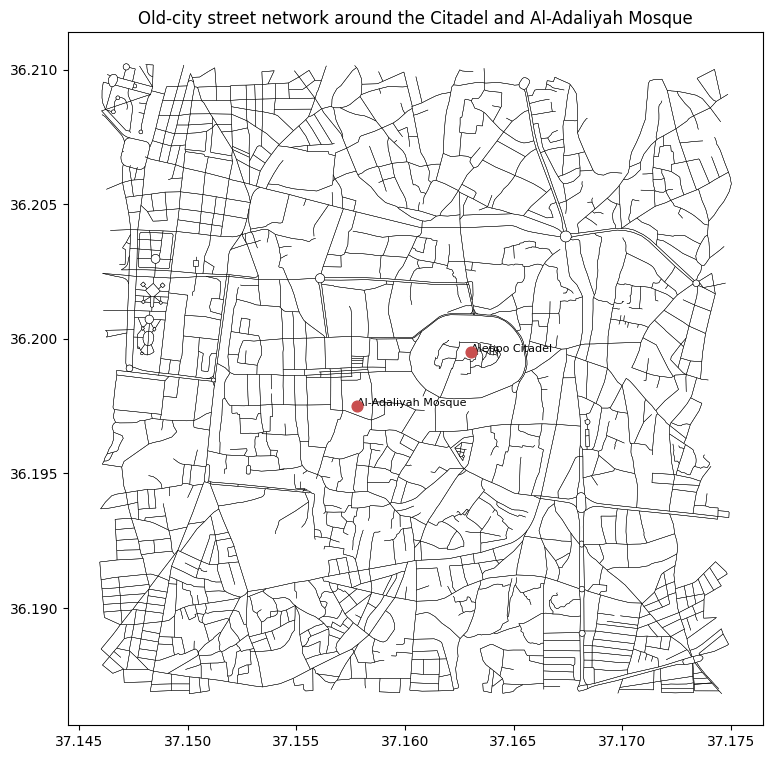

In [5]:
ax = net_edges.plot(color="black", linewidth=0.3, figsize=(9, 9))
landmarks_gdf.plot(ax=ax, color="#c94f4f", markersize=60, zorder=5)

for _, row in landmarks_gdf.iterrows():
    ax.text(row.geometry.x, row.geometry.y, row["name"], fontsize=8)

ax.set_title("Old-city street network around the Citadel and Al-Adaliyah Mosque")

Even at a glance, the network is not a clean grid: the Citadel's moat forces a
gap in the street fabric on its western edge, and the old-city alleys curve and
double back rather than running in straight lines toward the mosque.

## 3. Euclidean distance between the two landmarks

First, the straight-line distance. We project both points into UTM Zone 37N
(EPSG:32637), the appropriate metric CRS for Aleppo, so that `.distance()` returns
meters rather than degrees.

In [6]:
landmarks_utm = landmarks_gdf.to_crs(epsg=32637)
citadel_pt_utm = landmarks_utm.loc[
    landmarks_utm.id == "aleppo_citadel", "geometry"
].iloc[0]
mosque_pt_utm = landmarks_utm.loc[
    landmarks_utm.id == "aladaliyah_mosque", "geometry"
].iloc[0]

euclidean_distance_m = citadel_pt_utm.distance(mosque_pt_utm)
print(
    f"Euclidean distance, Citadel \u2194 Al-Adaliyah Mosque: {euclidean_distance_m:.0f} m"
)

Euclidean distance, Citadel ↔ Al-Adaliyah Mosque: 522 m


## 4. Network distance between the two landmarks

Now we snap each landmark to its nearest network node and find the shortest walking
path between them, using `length` as the routing weight — the same approach as the
restaurant-routing example in the tutorial.

In [7]:
citadel_node = ox.distance.nearest_nodes(
    network, landmarks.loc[0, "lon"], landmarks.loc[0, "lat"]
)
mosque_node = ox.distance.nearest_nodes(
    network, landmarks.loc[1, "lon"], landmarks.loc[1, "lat"]
)

route = ox.shortest_path(network, citadel_node, mosque_node, weight="length")
route_edges = ox.routing.route_to_gdf(network, route)
network_distance_m = route_edges["length"].sum()

print(
    f"Network distance, Citadel \u2194 Al-Adaliyah Mosque: {network_distance_m:.0f} m"
)
print(
    f"Detour factor (network / euclidean): {network_distance_m / euclidean_distance_m:.2f}x"
)

Network distance, Citadel ↔ Al-Adaliyah Mosque: 938 m
Detour factor (network / euclidean): 1.80x


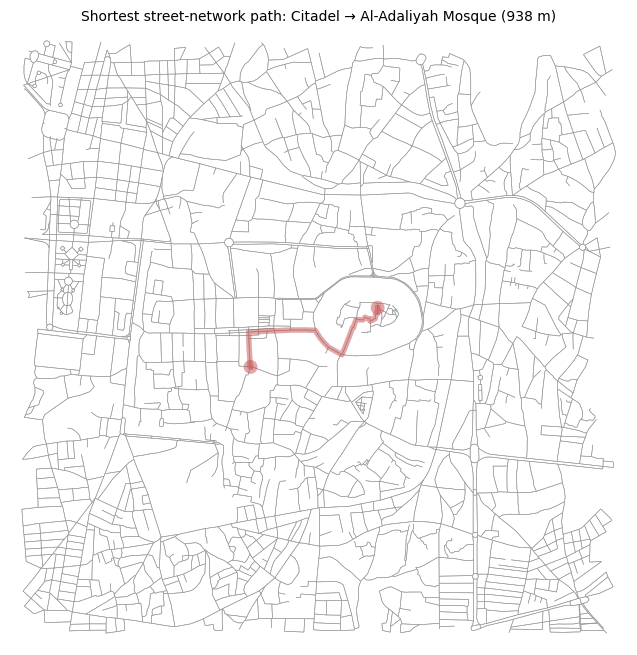

In [8]:
fig, ax = ox.plot_graph_route(
    network,
    route,
    route_color="#c94f4f",
    route_linewidth=4,
    node_size=0,
    bgcolor="white",
    edge_color="#999999",
    edge_linewidth=0.4,
    show=False,
    close=False,
)
ax.set_title(
    f"Shortest street-network path: Citadel \u2192 Al-Adaliyah Mosque ({network_distance_m:.0f} m)",
    fontsize=10,
)
plt.show()

The route immediately shows *why* the network distance is so much longer than
the straight line: there is no street through the Citadel's moat, so the path has to
travel around it before doubling back toward the mosque.

## 5. Comparing the two distances

A simple bar chart makes the gap concrete.

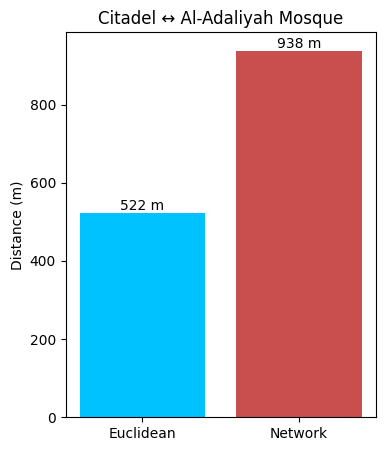

In [9]:
fig, ax = plt.subplots(figsize=(4, 5))
bars = ax.bar(
    ["Euclidean", "Network"],
    [euclidean_distance_m, network_distance_m],
    color=["#00c2ff", "#c94f4f"],
)
ax.bar_label(bars, fmt="%.0f m")
ax.set_ylabel("Distance (m)")
ax.set_title("Citadel \u2194 Al-Adaliyah Mosque")
plt.show()

## 6. Extending the network: relating it to conflict damage

The Citadel and the mosque don't exist in isolation — they sit inside a historic
quarter that the UNOSAT damage assessment surveyed at the level of individual
buildings (the same dataset used in
[`damage/aleppo_network_distance.ipynb`](../damage/aleppo_network_distance.ipynb)).
We load that point layer and keep only the buildings classified **Destroyed**
within the same study area as our street network, so we can ask: *how does network
distance reshape our sense of what's "nearby" once we're no longer just talking
about two landmarks?*

In [10]:
damage_path = (
    Path.cwd()
    / "../damage/damage data/damage sites aleppo/6_Damage_Sites_Aleppo_SDA.shp"
).resolve()

damage_sites = gpd.read_file(damage_path)
damage_sites_utm = damage_sites.to_crs(epsg=32637)
mid_pt_utm = (
    gpd.GeoSeries([Point(mid_lon, mid_lat)], crs="EPSG:4326").to_crs(epsg=32637).iloc[0]
)
damage_sites_utm["dist_to_study_area_m"] = damage_sites_utm.geometry.distance(
    mid_pt_utm
)

destroyed = damage_sites.loc[
    (damage_sites_utm["dist_to_study_area_m"] <= 600)
    & (damage_sites["DmgCls_4"] == "Destroyed")
].copy()

print(f"{len(destroyed)} buildings classified Destroyed within 600 m of the study area")

187 buildings classified Destroyed within 600 m of the study area


Text(0.5, 1.0, 'Destroyed buildings (red) around the Citadel and Al-Adaliyah Mosque')

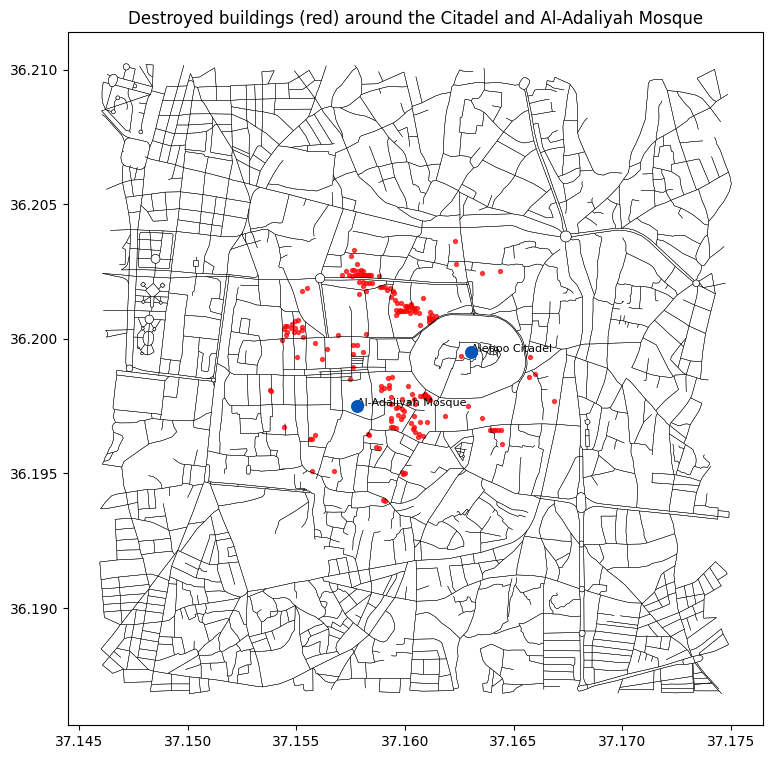

In [11]:
ax = net_edges.plot(color="black", linewidth=0.3, figsize=(9, 9))
destroyed.plot(ax=ax, color="#ff0000", markersize=8, alpha=0.7)
landmarks_gdf.plot(ax=ax, color="#0057b7", markersize=70, zorder=5)

for _, row in landmarks_gdf.iterrows():
    ax.text(row.geometry.x, row.geometry.y, row["name"], fontsize=8)

ax.set_title("Destroyed buildings (red) around the Citadel and Al-Adaliyah Mosque")

## 7. Nearest destroyed buildings, by network distance vs. Euclidean distance

Following the same pattern as the tutorial's "nearest pizza restaurants" example,
we write a function that, given a landmark's network node, finds the network
distance and route geometry to every destroyed building, then explode the results
back into columns of our geodataframe.

In [12]:
def distance_from_landmark(row, origin_node, graph):
    """Return the network distance (m) and route geometry from origin_node to row.geometry."""
    dest_node = ox.distance.nearest_nodes(graph, row.geometry.x, row.geometry.y)
    path = ox.shortest_path(graph, origin_node, dest_node, weight="length")
    edge_lengths = ox.routing.route_to_gdf(graph, path)["length"]
    route_geom = ox.routing.route_to_gdf(graph, path).geometry.union_all()
    return {"network_dist_m": edge_lengths.sum(), "route_geom": route_geom}

In [13]:
destroyed.loc[:, "from_citadel"] = destroyed.apply(
    distance_from_landmark, origin_node=citadel_node, graph=network, axis=1
)

destroyed = pd.concat(
    [
        destroyed.drop(columns=["from_citadel"]),
        destroyed["from_citadel"].apply(pd.Series).add_suffix("_citadel"),
    ],
    axis=1,
)
destroyed.head()

,SiteID,SensDt,SensorID,ConfID,DmgCls,SensDt_2,SensID_2,ConfID_2,DmgCls_2,DmgSts_2,...,DmgSts_4,GrpDmgCls,FldValid,Notes,StlmtNme,Neighbrhd,EventCode,geometry,network_dist_m_citadel,route_geom_citadel
16,Building (General / Default),NaT,NaN,NaN,NaN,2014-05-23,Worldview-2,Very High,Destroyed,New - damage,...,No change,Damaged Buildings,Not yet field validated,NaN,Aleppo,Al Jalloum,CE20130604SYR,POINT (37.16041 36.19777),426.638940,"MULTILINESTRING ((37.1633702 36.1996702, 37.16..."
1654,Building (General / Default),NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,New - damage,Damaged Buildings,Not yet field validated,NaN,Aleppo,Al Jalloum,CE20130604SYR,POINT (37.15442 36.19674),1320.163994,"MULTILINESTRING ((37.1633702 36.1996702, 37.16..."
1735,Building (General / Default),NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,New - damage,Damaged Buildings,Not yet field validated,NaN,Aleppo,Al Jalloum,CE20130604SYR,POINT (37.15671 36.19508),1183.786223,"MULTILINESTRING ((37.1633702 36.1996702, 37.16..."
1761,Building (General / Default),NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,New - damage,Damaged Buildings,Not yet field validated,NaN,Aleppo,Qalat Al-Sharif,CE20130604SYR,POINT (37.15907 36.19398),854.532467,"MULTILINESTRING ((37.1633702 36.1996702, 37.16..."
1762,Building (General / Default),NaT,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,New - damage,Damaged Buildings,Not yet field validated,NaN,Aleppo,Qalat Al-Sharif,CE20130604SYR,POINT (37.159 36.19401),854.532467,"MULTILINESTRING ((37.1633702 36.1996702, 37.16..."


In [14]:
destroyed_utm = destroyed.to_crs(epsg=32637)
destroyed["euclidean_dist_m_citadel"] = destroyed_utm.geometry.distance(
    citadel_pt_utm
).values
destroyed["detour_factor_citadel"] = (
    destroyed["network_dist_m_citadel"] / destroyed["euclidean_dist_m_citadel"]
)

nearest_to_citadel = destroyed.sort_values("network_dist_m_citadel").head(8)
nearest_to_citadel[
    [
        "SiteID",
        "Neighbrhd",
        "euclidean_dist_m_citadel",
        "network_dist_m_citadel",
        "detour_factor_citadel",
    ]
].reset_index(drop=True)

,SiteID,Neighbrhd,euclidean_dist_m_citadel,network_dist_m_citadel,detour_factor_citadel
0,Building (General / Default),Aleppo Citadel,43.093753,164.940596,3.827483
1,Building (General / Default),Al Jalloum,304.747597,426.638940,1.399975
2,Building (General / Default),Al Jalloum,268.551841,426.638940,1.588665
3,Building (General / Default),Al Jalloum,262.628683,426.638940,1.624495
4,Building (General / Default),Al Jalloum,257.354953,426.638940,1.657784
5,Building (General / Default),Al Jalloum,266.726767,426.638940,1.599536
6,Building (General / Default),Al Jalloum,260.624626,426.638940,1.636986
7,Building (General / Default),Al Jalloum,264.949665,426.638940,1.610264


Let's do the same from the mosque's side, so we can compare how the two
landmarks relate to the same set of destroyed buildings.

In [15]:
destroyed.loc[:, "from_mosque"] = destroyed.apply(
    distance_from_landmark, origin_node=mosque_node, graph=network, axis=1
)

destroyed = pd.concat(
    [
        destroyed.drop(columns=["from_mosque"]),
        destroyed["from_mosque"].apply(pd.Series).add_suffix("_mosque"),
    ],
    axis=1,
)

destroyed["euclidean_dist_m_mosque"] = destroyed_utm.geometry.distance(
    mosque_pt_utm
).values
destroyed["detour_factor_mosque"] = (
    destroyed["network_dist_m_mosque"] / destroyed["euclidean_dist_m_mosque"]
)

nearest_to_mosque = destroyed.sort_values("network_dist_m_mosque").head(8)
nearest_to_mosque[
    [
        "SiteID",
        "Neighbrhd",
        "euclidean_dist_m_mosque",
        "network_dist_m_mosque",
        "detour_factor_mosque",
    ]
].reset_index(drop=True)

,SiteID,Neighbrhd,euclidean_dist_m_mosque,network_dist_m_mosque,detour_factor_mosque
0,Building (General / Default),Al Jalloum,123.858007,164.378961,1.327157
1,Building (General / Default),Qalat Al-Sharif,129.706846,164.378961,1.267311
2,Building (General / Default),Al Jalloum,114.586503,198.893196,1.735747
3,Building (General / Default),Al Jalloum,172.343882,220.193137,1.277638
4,Building (General / Default),Al Jalloum,150.689281,220.193137,1.461240
5,Building (General / Default),Al Jalloum,146.207102,220.193137,1.506036
6,Building (General / Default),Al Jalloum,161.882525,220.193137,1.360203
7,Building (General / Default),Al Jalloum,160.249444,220.578385,1.376469


The `detour_factor` column (network distance ÷ Euclidean distance) is the
useful number here: a value of `1.0` means the street network offers a nearly
direct path, while higher values mean the building is functionally farther than it
looks on a straight-line map. Let's compare the distribution of detour factors
around each landmark.

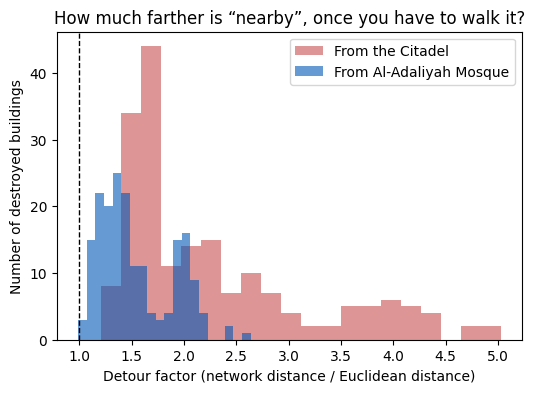

       detour_factor_citadel  detour_factor_mosque
count             187.000000            187.000000
mean                2.271722              1.536572
std                 0.928815              0.347943
min                 1.204339              0.987774
25%                 1.601682              1.265067
50%                 1.885467              1.422325
75%                 2.683736              1.899782
max                 5.027128              2.637985


In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    destroyed["detour_factor_citadel"],
    bins=20,
    alpha=0.6,
    label="From the Citadel",
    color="#c94f4f",
)
ax.hist(
    destroyed["detour_factor_mosque"],
    bins=20,
    alpha=0.6,
    label="From Al-Adaliyah Mosque",
    color="#0057b7",
)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Detour factor (network distance / Euclidean distance)")
ax.set_ylabel("Number of destroyed buildings")
ax.set_title("How much farther is \u201cnearby\u201d, once you have to walk it?")
ax.legend()
plt.show()

print(destroyed[["detour_factor_citadel", "detour_factor_mosque"]].describe())

The Citadel's distribution sits visibly further right than the mosque's — a
direct consequence of the moat: almost nothing can be reached from the Citadel
without a detour, whereas many buildings around the mosque, sitting inside the
denser but unobstructed old-city grid, are reachable close to as-the-crow-flies.

## 8. Mapping the nearest destroyed buildings

We'll plot the 8 buildings nearest the Citadel by network distance, colored by
distance, with their routed paths drawn in — the same style as the tutorial's pizza
map.

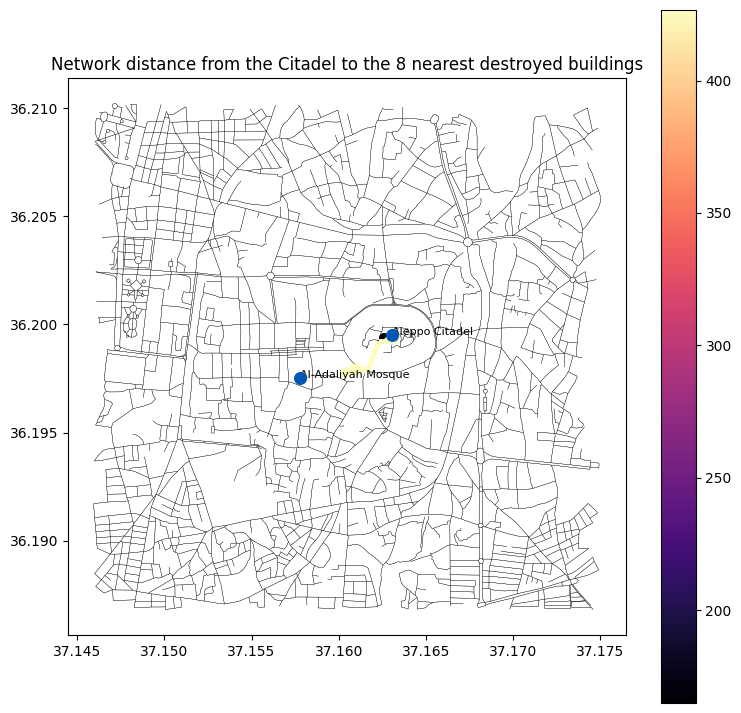

In [17]:
nearest_to_citadel_routes = gpd.GeoDataFrame(
    nearest_to_citadel, geometry="route_geom_citadel", crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(9, 9))
net_edges.plot(ax=ax, color="black", linewidth=0.2)
nearest_to_citadel_routes.plot(
    column="network_dist_m_citadel", cmap="magma", ax=ax, linewidth=3
)
nearest_to_citadel.plot(
    column="network_dist_m_citadel", cmap="magma", legend=True, ax=ax, markersize=40
)
landmarks_gdf.plot(ax=ax, color="#0057b7", markersize=70, zorder=5)

for _, row in landmarks_gdf.iterrows():
    ax.text(row.geometry.x, row.geometry.y, row["name"], fontsize=8)

ax.set_title("Network distance from the Citadel to the 8 nearest destroyed buildings")
plt.show()

## 9. Overview map, on our Mapbox basemap

Finally, we'll bring everything together on a `plotly` `Scattermapbox`, using the
same Mapbox access token and light basemap style used throughout this repo (see
[`commute/commute_network.ipynb`](../commute/commute_network.ipynb)): the full
street network, the destroyed buildings, and — for the Citadel/mosque pair
specifically — both the straight Euclidean line and the actual routed network
path, so the gap between them is visible directly on the map rather than just in
the numbers above.

In [18]:
MAPBOX_TOKEN = "pk.eyJ1Ijoia2hhbGVkYWxhbmplcnkiLCJhIjoiY21zOXJtdGE3MHM5NDJ3b2RhZDhlN3RzdiJ9.u-954HDL1cS8ZVODaKr3IQ"

route_coords = [(network.nodes[n]["x"], network.nodes[n]["y"]) for n in route]
route_lons = [c[0] for c in route_coords]
route_lats = [c[1] for c in route_coords]

fig = go.Figure()

# street network, drawn thin and faint
for _, edge in net_edges.iterrows():
    xs, ys = edge.geometry.xy
    fig.add_trace(
        go.Scattermapbox(
            lon=list(xs),
            lat=list(ys),
            mode="lines",
            line=dict(width=1, color="#bbbbbb"),
            hoverinfo="skip",
            showlegend=False,
        )
    )

# destroyed buildings
fig.add_trace(
    go.Scattermapbox(
        lon=destroyed.geometry.x,
        lat=destroyed.geometry.y,
        mode="markers",
        marker=dict(size=6, color="#ff0000", opacity=0.6),
        text=destroyed["Neighbrhd"],
        hovertemplate="Destroyed building<br>%{text}<extra></extra>",
        name="Destroyed buildings",
    )
)

# Euclidean line, Citadel <-> Mosque
fig.add_trace(
    go.Scattermapbox(
        lon=[landmarks.loc[0, "lon"], landmarks.loc[1, "lon"]],
        lat=[landmarks.loc[0, "lat"], landmarks.loc[1, "lat"]],
        mode="lines",
        line=dict(width=3, color="#00c2ff"),
        name=f"Euclidean ({euclidean_distance_m:.0f} m)",
    )
)

# routed network path, Citadel -> Mosque
fig.add_trace(
    go.Scattermapbox(
        lon=route_lons,
        lat=route_lats,
        mode="lines",
        line=dict(width=4, color="#c94f4f"),
        name=f"Network route ({network_distance_m:.0f} m)",
    )
)

# the two landmarks
fig.add_trace(
    go.Scattermapbox(
        lon=landmarks.lon,
        lat=landmarks.lat,
        mode="markers+text",
        marker=dict(size=14, color="#0057b7", symbol="star"),
        text=landmarks.name,
        textposition="top center",
        name="Landmarks",
    )
)

fig.update_layout(
    title="Aleppo Citadel \u2194 Al-Adaliyah Mosque: Euclidean vs. network distance",
    mapbox=dict(
        style="mapbox://styles/mapbox/light-v10",
        center=dict(lat=mid_lat, lon=mid_lon),
        zoom=15,
        accesstoken=MAPBOX_TOKEN,
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    width=1000,
    height=750,
)

fig.show()

### Saving our datasets

As in the tutorial, we can optionally save the network and the landmark/damage
nodes out as GeoJSON for use in QGIS or elsewhere.

In [ ]:
net_nodes[["geometry"]].to_file("network_nodes.geojson", driver="GeoJSON")
net_edges[["geometry"]].to_file("network_edges.geojson", driver="GeoJSON")
landmarks_gdf.to_file("landmark_nodes.geojson", driver="GeoJSON")
destroyed[["SiteID", "Neighbrhd", "DmgCls_4", "geometry"]].to_file(
    "destroyed_buildings.geojson", driver="GeoJSON"
)
print(
    "Saved network_nodes.geojson, network_edges.geojson, landmark_nodes.geojson, destroyed_buildings.geojson"
)

## Reflection

The headline number is the detour factor: the Citadel and Al-Adaliyah Mosque are
**522 m apart as the crow flies, but 938 m apart on foot** — a 1.8x stretch caused
entirely by the Citadel's moat and mound, which push any pedestrian route around
its perimeter before it can double back toward the mosque. Euclidean distance
describes a relationship that doesn't exist on the ground; only the network
distance describes a walk anyone could actually take.

That gap gets more interesting once we widen the network to the surrounding
destroyed buildings. Buildings near the mosque, sitting inside the ordinary
(if severely damaged) street grid of the old city, mostly have detour factors close
to `1.0` — Euclidean distance is a reasonable stand-in for how far they feel. But
almost every destroyed building near the Citadel inherits some fraction of its
moat penalty: proximity on the map does not translate to proximity on foot, because
the fortress geometry that has stood for centuries still organizes movement through
the neighborhood today. In other words, the *same physical obstacle* that shapes
the tourist's or resident's mental map of the old city also shapes which buildings
count as "near" each other in this damage dataset — the Citadel's built form
structures spatial relationships well beyond its own walls.

There's also a limit worth naming: even network distance, as computed here,
is generous. `OSMnx` returns the *current* street graph — it doesn't know which of
these streets were passable during the period the UNOSAT damage assessment
describes, when rubble, collapsed facades, and checkpoints could close a street
that shows up as walkable on OpenStreetMap today. The real, lived distance during
the conflict was very likely longer, and less predictable, than either the
Euclidean or the network figure calculated here. Network distance is a meaningful
correction to the straight line, but it is still a peacetime approximation of a
wartime city — a reminder that "distance" in a damage-mapping context is not
just geometric, but historical and conditional on when, exactly, you're asking.